In [78]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score

In [79]:
data=pd.read_csv(r"C:\Users\Lenovo\Documents\Notes\MARCH\27th- l1, l2, scaling\lasso, ridge, elastic net\TASK-22_LASSO,RIDGE\car-mpg.csv")
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino


In [80]:
data.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'origin', 'car_type',
       'car_name'],
      dtype='object')

In [71]:
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino


In [86]:
data = data.drop(['car_name'], axis = 1)
data['origin'] = data['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
data = pd.get_dummies(data,columns = ['origin'])
data = data.replace('?', np.nan)
data = data.apply(lambda x: x.fillna(x.median()), axis = 0)

In [87]:
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130.0,3504,12.0,70,0,True,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,0,True,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,0,True,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,0,True,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,0,True,False,False


In [88]:
print(data.dtypes)

mpg               float64
cyl                 int64
disp              float64
hp                float64
wt                  int64
acc               float64
yr                  int64
car_type            int64
origin_america       bool
origin_asia          bool
origin_europe        bool
dtype: object


In [83]:
data = data.apply(pd.to_numeric, errors='coerce')

In [89]:
print(data.isnull().sum())
data=data.astype(int)

mpg               0
cyl               0
disp              0
hp                0
wt                0
acc               0
yr                0
car_type          0
origin_america    0
origin_asia       0
origin_europe     0
dtype: int64


In [90]:
x=data.drop(['mpg'],axis=1)
y=data[['mpg']]

In [91]:
x_s=preprocessing.scale(x)
x_s=pd.DataFrame(x_s,columns=x.columns)
y_s=preprocessing.scale(y)
y_s=pd.DataFrame(y_s,columns=y.columns)

In [92]:
x_train, x_test, y_train,y_test = train_test_split(x, y, test_size = 0.30, random_state = 1)
x_train.shape

(278, 10)

In [93]:
data.isnull().sum()

mpg               0
cyl               0
disp              0
hp                0
wt                0
acc               0
yr                0
car_type          0
origin_america    0
origin_asia       0
origin_europe     0
dtype: int64

In [95]:
regression_model = LinearRegression()
regression_model.fit(x_train, y_train)

for idx, col_name in enumerate(x_train.columns):
    print('The coefficient for {} is {}'.format(col_name, regression_model.coef_[0][idx]))
    
intercept = regression_model.intercept_[0]
print('The intercept is {}'.format(intercept))

The coefficient for cyl is 1.4667698197721373
The coefficient for disp is 0.024567630327403573
The coefficient for hp is -0.04751268600038756
The coefficient for wt is -0.006533919605283123
The coefficient for acc is 0.0449592651542386
The coefficient for yr is 0.7599370612656587
The coefficient for car_type is 6.006530035298926
The coefficient for origin_america is -1.4266113703103307
The coefficient for origin_asia is 0.6528198633452179
The coefficient for origin_europe is 0.7737915069651342
The intercept is -25.886422899655454


In [96]:
ridge_model = Ridge(alpha = 0.3)
ridge_model.fit(x_train, y_train)
print('Ridge model coef: {}'.format(ridge_model.coef_))

Ridge model coef: [ 1.40278817  0.02473141 -0.04663475 -0.00655892  0.04580876  0.76100817
  5.81936577 -1.43049689  0.64826957  0.78222732]


In [97]:
lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(x_train, y_train)
print('Lasso model coef: {}'.format(lasso_model.coef_))

Lasso model coef: [ 0.06139588  0.02735162 -0.03127805 -0.00679856  0.02680019  0.75427505
  2.63282384 -1.65462154  0.          0.        ]


In [98]:
#Simple Linear Model

print(regression_model.score(x_train, y_train))
print(regression_model.score(x_test, y_test))
print('*************************')

#Ridge:

print(ridge_model.score(x_train, y_train))
print(ridge_model.score(x_test, y_test))
print('*************************')

#Lasso:

print(lasso_model.score(x_train, y_train))
print(lasso_model.score(x_test, y_test))

0.8322467131578638
0.8479247166489299
*************************
0.832226013322011
0.8483718745457652
*************************
0.8234938700695027
0.8492603679964902


In [99]:
poly = PolynomialFeatures(degree = 2, interaction_only = True)
x_poly = poly.fit_transform(x_s)

In [100]:
data_train_test = pd.concat([x_train, y_train], axis =1)
data_train_test.head()

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe,mpg
350,4,105,63,2215,14,81,1,1,0,0,34
59,4,97,54,2254,23,72,1,0,0,1,23
120,4,121,112,2868,15,73,1,0,0,1,19
12,8,400,150,3761,9,70,0,1,0,0,15
349,4,91,68,1985,16,81,1,0,1,0,34


In [101]:
import statsmodels.formula.api as smf
ols1 = smf.ols(formula = 'mpg ~ cyl+disp+hp+wt+acc+yr+car_type+origin_america+origin_europe+origin_asia', data = data_train_test).fit()
ols1.params

Intercept        -19.414817
cyl                1.466770
disp               0.024568
hp                -0.047513
wt                -0.006534
acc                0.044959
yr                 0.759937
car_type           6.006530
origin_america    -7.898217
origin_europe     -5.697814
origin_asia       -5.818786
dtype: float64

In [102]:
ols1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     147.7
Date:                Fri, 28 Mar 2025   Prob (F-statistic):           1.71e-98
Time:                        11:48:00   Log-Likelihood:                -717.58
No. Observations:                 278   AIC:                             1455.
Df Residuals:                     268   BIC:                             1491.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -19.4148      4.150     -4.678      0.000     -27.586     -11.244
cyl                1.4668      0.516      2.843      0.005       0.451       2.483
disp               0.0246      0.010      2.580      0.010       0.006       0.043
hp                -0.0475      0.016     -2.961      0.003      -0.079      -0.016
wt                -0.0065      0.001     -8.174      0.000      -0.008      -0.005
acc                0.0450      0.109      0.411      0.681      -0.170       0.260
yr                 0.7599      0.061     12.513      0.000       0.640       0.880
car_type           6.0065      1.040      5.774      0.000       3.958       8.055
origin_america    -7.8982      1.464     -5.394      0.000     -10.781      -5.015
origin_europe     -5.6978      1.387     -4.107      0.000      -8.429      -2.966
origin_asia       -5.8188      1.455     -4.000      0.000      -8.683      -2.955
==============================================================================
Omnibus:                       21.334   Durbin-Watson:                   2.095
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               32.128
Skew:                           0.506   Prob(JB):                     1.06e-07
Kurtosis:                       4.322   Cond. No.                     1.96e+19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 6.87e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [103]:
mse  = np.mean((regression_model.predict(x_test)-y_test)**2)
import math
rmse = math.sqrt(mse)
print('Root Mean Squared Error: {}'.format(rmse))

Root Mean Squared Error: 2.9593016756394905


<Axes: xlabel='acc', ylabel='mpg'>

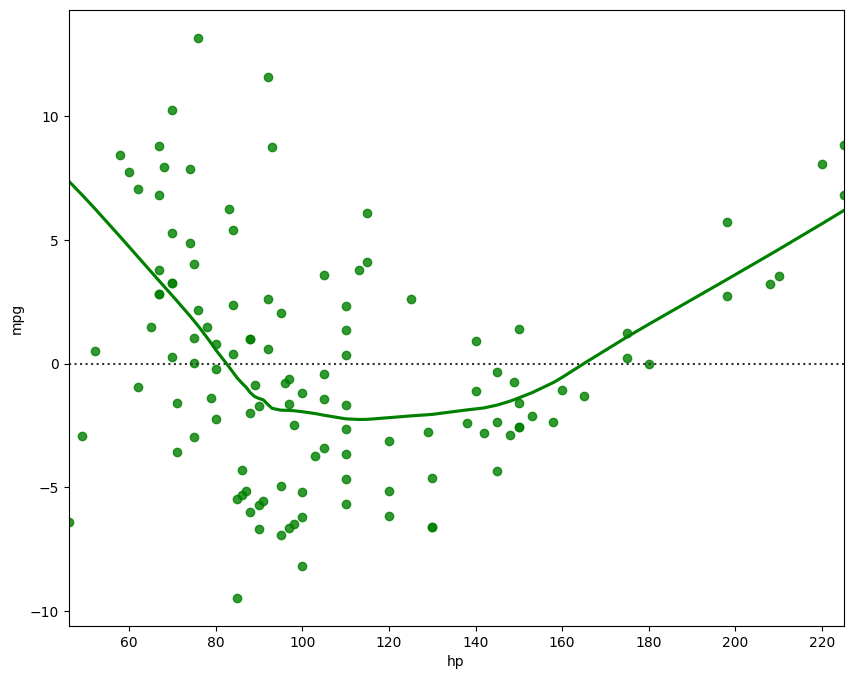

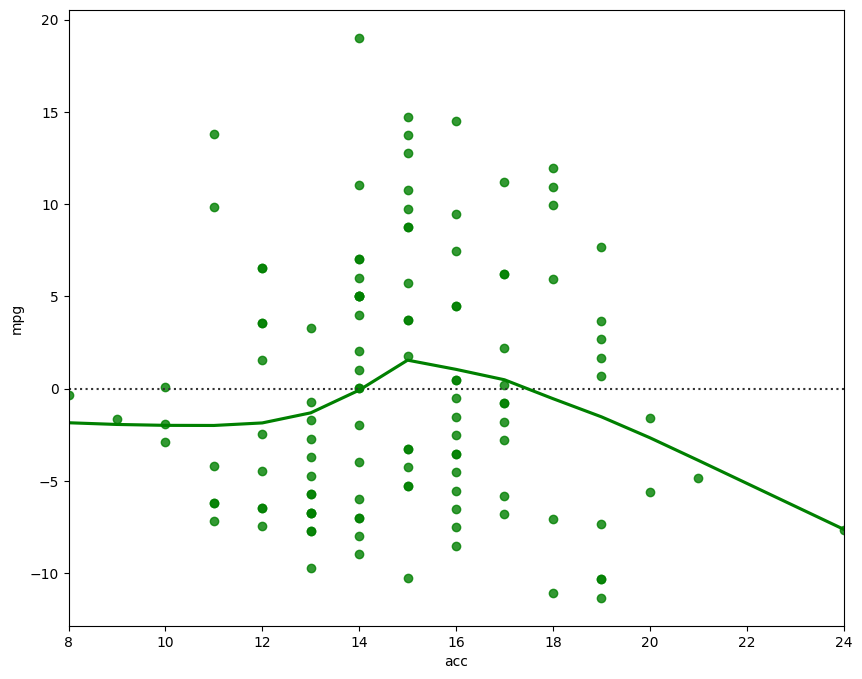

In [104]:
fig = plt.figure(figsize=(10,8))
sns.residplot(x= x_test['hp'], y= y_test['mpg'], color='green', lowess=True )

fig = plt.figure(figsize=(10,8))
sns.residplot(x= x_test['acc'], y= y_test['mpg'], color='green', lowess=True )

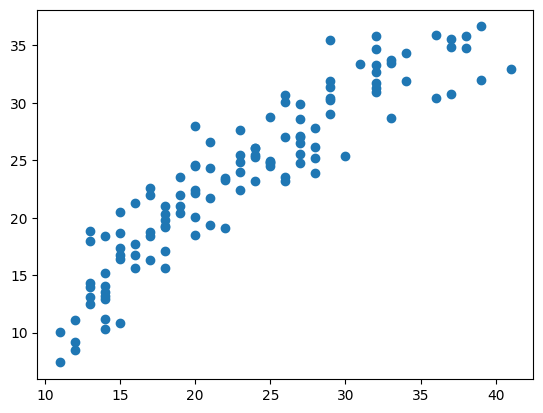

In [105]:
y_pred = regression_model.predict(x_test)
plt.scatter(y_test['mpg'], y_pred)